# Heterogeneous Treatment Effects

## Background

Impact evaluations often focus on estimating the average effect of a program across all participants. While average treatment effects provide important information about overall program effectiveness, they do not reveal whether certain groups benefit more than others.

Education interventions may affect pupils differently depending on their characteristics. Younger learners may respond differently than older learners, and the magnitude of learning gains may vary across demographic groups.

Heterogeneous Treatment Effects (HTE) analysis explores whether program impacts differ across subgroups of the population. Rather than asking:

> Did the program work?

HTE analysis asks:

> Who benefited most from the program?

Understanding these differences can help policymakers and programme implementers improve targeting, allocate resources more efficiently, and design more equitable interventions.

In this study, subgroup analyses are conducted for:

- Primary 5 versus Primary 6 pupils
- Girls versus Boys

The objective is to assess whether the estimated impact of the education support program differs across these groups.

## Research Questions

1. Did the program have different impacts on Primary 5 and Primary 6 pupils?
2. Did the program have different impacts on girls and boys?
3. Which groups experienced the largest learning gains following program participation?

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "../data/synthetic_education_data.csv"
                 )

df.head

<bound method NDFrame.head of      student_id class_level gender  treatment  attendance_rate  study_hours  \
0             1          P5   Girl          1             92.3          6.6   
1             2          P6    Boy          1             89.8          3.7   
2             3          P5   Girl          1             95.8         10.9   
3             4          P5    Boy          0             81.2          6.3   
4             5          P5    Boy          0             89.4          6.2   
..          ...         ...    ...        ...              ...          ...   
475         236          P6   Girl          1             78.8         10.9   
476         237          P6    Boy          0             76.1          4.7   
477         238          P6   Girl          1             92.5          4.9   
478         239          P5    Boy          1             88.3          4.8   
479         240          P6   Girl          1             84.7          4.9   

     post      time  

In [6]:
# Estimate Effects by Class Grade

grade_results = []

for grade in ["P5", "P6"]:
    
    subset = df[
        df["class_level"] == grade
    ]
    
    model = smf.ols(
        "test_score ~ treatment * post",
        data=subset
    ).fit()
    
    grade_results.append({
        "Group": grade,
        "Impact": model.params["treatment:post"]
    })

grade_results = pd.DataFrame(
    grade_results
)

grade_results

,Group,Impact
0,P5,7.419373
1,P6,7.028893


In [ ]:
grade_results.to_csv(
    "../outputs/tables/grade_heterogeneous_effects.csv",
    index=False
)

<Axes: xlabel='Group', ylabel='Impact'>

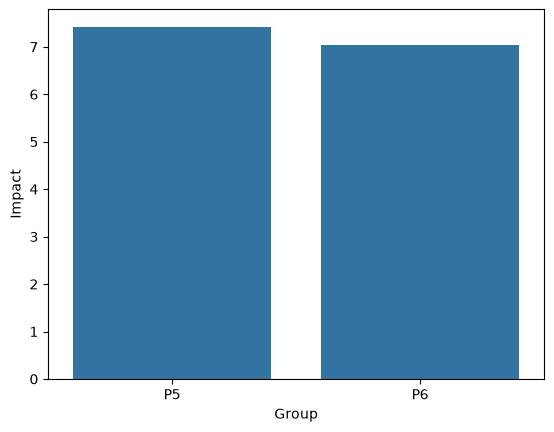

In [11]:
sns.barplot(
    data=grade_results,
    x="Group",
    y="Impact"
)

In [ ]:
#Estimating Effects by Gender

gender_results = []

for gender in ["Girl", "Boy"]:
    
    subset = df[
        df["gender"] == gender
    ]

    model = smf.ols(
        "test_score ~ treatment * post",
        data=subset
    ).fit()

    gender_results.append({
        "Group": gender,
        "Impact": model.params["treatment:post"]
    })

gender_results = pd.DataFrame(
    gender_results
    )

gender_results

,Group,Impact
0,Girl,7.534608
1,Boy,6.882020


In [14]:
gender_results.to_csv(
    "../outputs/tables/gender_heterogeneous_effects.csv",
    index=False
)

<Axes: xlabel='Group', ylabel='Impact'>

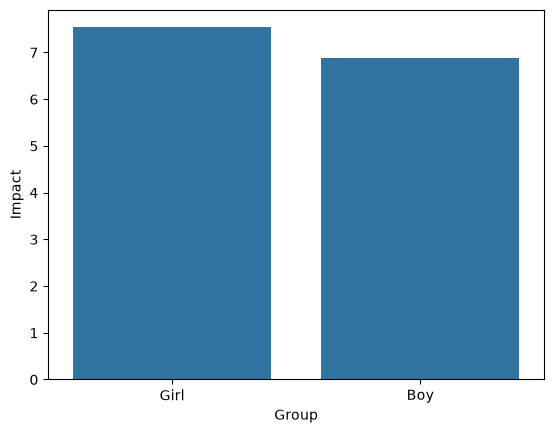

In [10]:
sns.barplot(
    data=gender_results,
    x="Group",
    y="Impact"
)

## Interpretation of Heterogeneous Treatment Effects

The Heterogeneous Treatment Effects (HTE) analysis was conducted to assess whether the impact of the education support program varied across pupil subgroups.

### Program Impact by Class Level

| Group | Estimated Impact (Points) |
|----------|-------------------------:|
| Primary 5 | 7.42 |
| Primary 6 | 7.03 |

The estimated effect of the program was positive for both Primary 5 and Primary 6 pupils.

Primary 5 pupils experienced an estimated improvement of approximately **7.42 points**, while Primary 6 pupils experienced an estimated improvement of approximately **7.03 points**.

Although the effect was slightly larger among Primary 5 pupils, the difference between the two grade levels was relatively small. This suggests that the program generated learning gains across both upper-primary cohorts rather than benefiting only one grade level.

### Program Impact by Gender

| Group | Estimated Impact (Points) |
|----------|-------------------------:|
| Girls | 7.53 |
| Boys | 6.88 |

The program also produced positive effects for both girls and boys.

Girls experienced an estimated gain of approximately **7.53 points**, while boys experienced an estimated gain of approximately **6.88 points**.

The slightly larger effect among girls may suggest that female pupils benefited somewhat more from the intervention. However, both groups experienced substantial improvements in learning outcomes.

### Key Findings

Three important conclusions emerge from the analysis:

1. The program produced positive learning gains across all examined subgroups.
2. Differences in estimated impacts across grades and gender were relatively modest.
3. There is no evidence that the intervention benefited only a specific subgroup of pupils.

### Policy Implications

The findings suggest that the education support program has broad applicability across different pupil populations. Because positive impacts were observed among both grades and both gender groups, the intervention may be suitable for scale-up without requiring major redesign for specific subpopulations.

At the same time, the slightly larger impacts observed among Primary 5 pupils and among girls may warrant further investigation in future evaluations to better understand differences in program responsiveness.

### Evaluation Takeaway

The education support program appears to have generated meaningful improvements in learning outcomes across all examined subgroups. The consistency of impacts suggests that the intervention is broadly effective and capable of supporting learning gains among diverse groups of pupils.